In [1]:
import pandas as pd

# Load correct dataset
data = pd.read_csv("dataset/train.csv")

# Show first rows
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
data.shape

(1460, 81)

In [3]:
data.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

In [4]:
features = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'TotalBsmtSF',
    'FullBath',
    'YearBuilt'
]

X = data[features]
y = data['SalePrice']

print(X.head())

   OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  FullBath  \
0            7       1710           2         548          856         2   
1            6       1262           2         460         1262         2   
2            7       1786           2         608          920         2   
3            7       1717           3         642          756         1   
4            8       2198           3         836         1145         2   

   YearBuilt  
0       2003  
1       1976  
2       2001  
3       1915  
4       2000  


In [5]:
X = X.fillna(X.mean())

print("Missing values handled")

Missing values handled


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained")

Model trained


In [7]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.7950095261783591


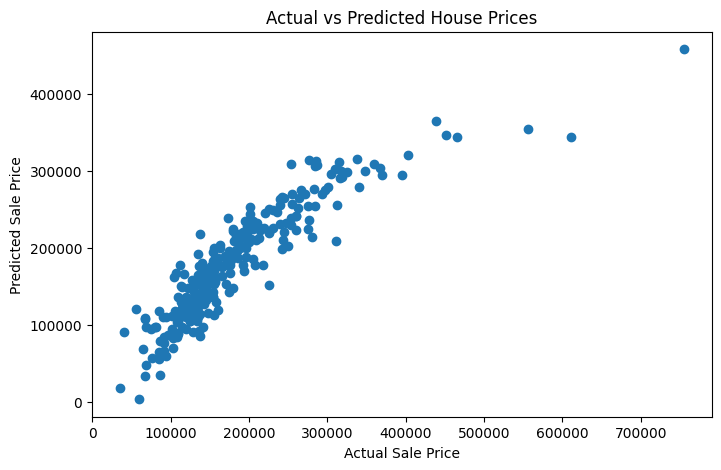

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("images/prediction_graph.png")

plt.show()

In [9]:
new_house = [[7, 1500, 2, 500, 800, 2, 2005]]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 204590.38271163788


c:\Users\hruda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
